In [2]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import GroupShuffleSplit


import sys
sys.path.append("../")

def retime(df):
    """
    Recalculate segment time, treating the entire dataframe as one segment.

    Args:
        df (pd.DataFrame): Measurement data. Includes a column
                           'Segment Time, S'

    Returns:
        pd.DataFrame: Dataframe where 'Segment Time, S' is reindexed
                      to start from 0.
    """
    df_ = df.copy().reset_index(drop=True)
    df_["Segment Time, S"] = df_["Total Time, S"] - df_.loc[0, "Total Time, S"]
    return df_
segments_of_interest = [
    "Charge depleting cycle",
    "Charge sustaining cycle",
    'Rate test C/2 cycle charge CC',
    'PsRP 1 C/2 diagnostic cycle charge',
    'PsRP 2 C/2 diagnostic cycle charge',
    'Rate test 1C cycle charge CC',
    'PsRP 1 1C diagnostic cycle charge',
    'PsRP 2 1C diagnostic cycle charge',
]

In [2]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, max_error, classification_report, confusion_matrix, ConfusionMatrixDisplay

def plot_true_vs_pred_axis(ax, pulse, target, result_dict, color='blue', n_splits=50, title=''):
    df = result_dict[f"{target}, {pulse}"]
    average_pred = df[list(range(n_splits))].mean(axis=1)
    sns.histplot(x=df[target],
        y=average_pred,
        stat='percent',
        bins=30,
        color=color,
        ax=ax)
    ax.axline( (df[target].min(), df[target].min()),
                       (df[target].max(), df[target].max()),
                     linestyle='dashed', color='gray')
    ax.set_title(title)
    ax.annotate("r^2: {:.3f}".format(r2_score(df[target], average_pred)), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=8)

In [19]:
A_discharge = torch.load('../../results/neural_network/mse/PsRP_2_C_2_C_3 discharge capacity_A_model.pth')
B_discharge = torch.load('../../results/neural_network/mse/PsRP_2_C_2_C_3 discharge capacity_B_model.pth')
C_discharge = torch.load('../../results/neural_network/mse/PsRP_2_C_2_C_3 discharge capacity_C_model.pth')
D_discharge = torch.load('../../results/neural_network/mse/PsRP_2_C_2_C_3 discharge capacity_D_model.pth')

A_soc = torch.load('../../results/neural_network/mse/PsRP_2_C_2_soc_mean_A_model.pth')
B_soc = torch.load('../../results/neural_network/mse/PsRP_2_C_2_soc_mean_B_model.pth')
C_soc = torch.load('../../results/neural_network/mse/PsRP_2_C_2_soc_mean_C_model.pth')
D_soc = torch.load('../../results/neural_network/mse/PsRP_2_C_2_soc_mean_D_model.pth')

hdf = pd.HDFStore("../../data/data_partial_charge_for_ml.h5", mode="r")
df_all = hdf.get("PsRP_2_C/2")



In [3]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

class DataFrameDataset(Dataset):
    # def __init__(self, h5_path, key, target, transform=None):
    def __init__(self, dataframe, target, transform=None):
        # self.h5_path = h5_path
        # self.key = key
        # self.data_cache = pd.HDFStore(self.h5_path)
        # self.data = self.data_cache[self.key]
        self.data = dataframe
        self.transform = transform
        self.targets = self.data[target]
        # if self.data['voltage_0.0s'].isna().any():
        #     self.data = self.data.drop(['voltage_0.0s', 'current_0.0s', 'power_0.0s'], axis=1).reset_index(drop=True)
        #     self.targets = self.data[target].reset_index(drop=True)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data.iloc[idx]
        sample = sample.filter(regex="voltage|current|power")

        target = self.targets.iloc[idx]
        if self.transform:
            sample = self.transform(sample)
        return sample, target.astype("float32")

class ToTensor(object):
    """Convert pandas dataframe sample to tensor."""
    def __call__(self, sample):
        return torch.tensor(sample, dtype=torch.float)

C:\Users\etenney\AppData\Local\Temp\1\ipykernel_10416\92790354.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return torch.tensor(sample, dtype=torch.float)
C:\Users\etenney\AppData\Local\Temp\1\ipykernel_10416\92790354.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return torch.tensor(sample, dtype=torch.float)
C:\Users\etenney\AppData\Local\Temp\1\ipykernel_10416\92790354.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[po

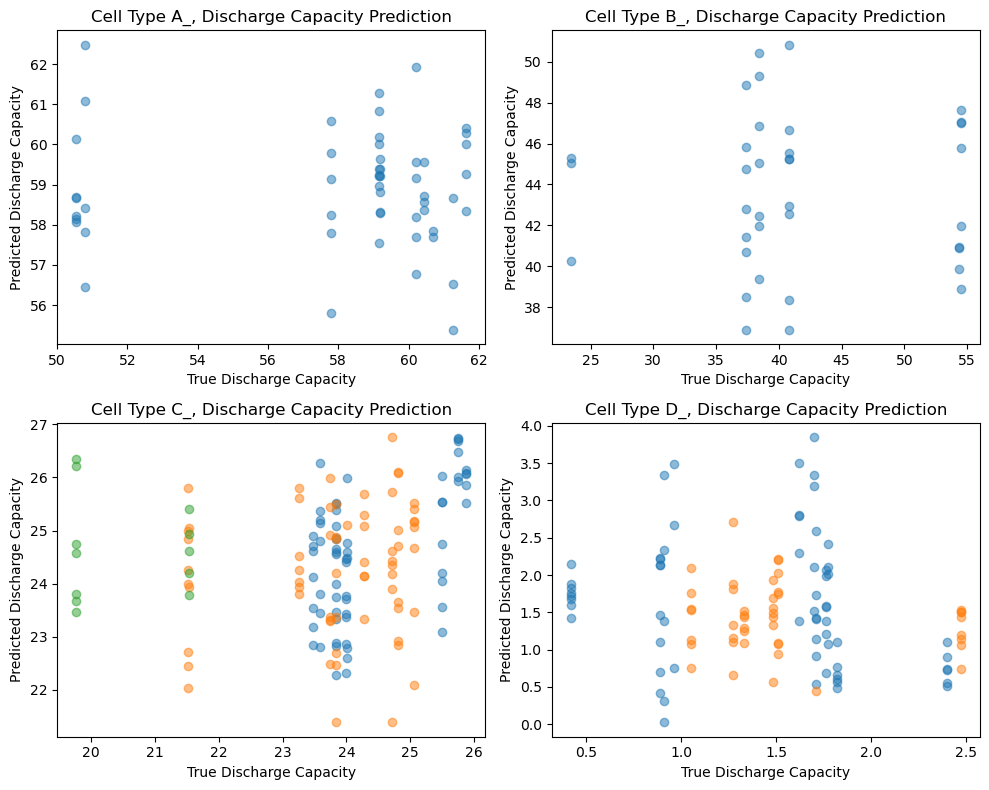

In [23]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax = ax.flatten()

for i, (cell_type, model_state) in enumerate(zip(["A_", "B_", "C_", "D_"], [A_discharge, B_discharge, C_discharge, D_discharge])):
    df = df_all[df_all["cell_id"].str.startswith(cell_type)].reset_index(drop=True)

    splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    df = df.groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    idx_train, idx_test = next(splitter.split(df, groups=df["measurement_id"]))
    df_train = df.iloc[idx_train].reset_index(drop=True)
    df_test = df.iloc[idx_test].reset_index(drop=True)

    ax[i].set_title(f"Cell Type {cell_type}, Discharge Capacity Prediction")
    test_dataloader = DataLoader(DataFrameDataset(df_test, target="C/3 discharge capacity", transform=ToTensor()), batch_size=64, shuffle=False)

    model = NeuralNetwork(input_size= df_test.filter(regex="voltage|current|power").shape[1], hidden_size=512, output_size=1)
    model.load_state_dict(model_state)
    model.eval()
    with torch.no_grad():
        for X, y in test_dataloader:
            outputs = model(X)
            ax[i].scatter(y.numpy(), outputs.numpy(), alpha=0.5)
            ax[i].set_xlabel("True Discharge Capacity")
            ax[i].set_ylabel("Predicted Discharge Capacity")


fig.tight_layout()

C:\Users\etenney\AppData\Local\Temp\1\ipykernel_10416\92790354.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return torch.tensor(sample, dtype=torch.float)
C:\Users\etenney\AppData\Local\Temp\1\ipykernel_10416\92790354.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return torch.tensor(sample, dtype=torch.float)
C:\Users\etenney\AppData\Local\Temp\1\ipykernel_10416\92790354.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[po

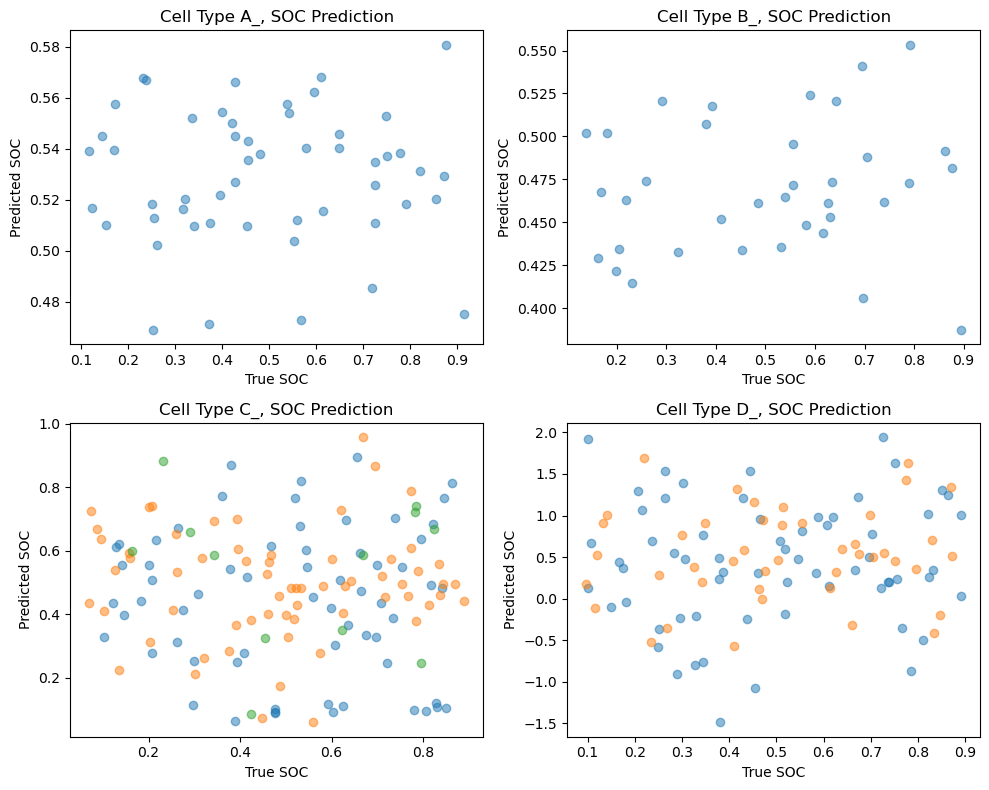

In [22]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax = ax.flatten()

for i, (cell_type, model_state) in enumerate(zip(["A_", "B_", "C_", "D_"], [A_soc, B_soc, C_soc, D_soc])):
    df = df_all[df_all["cell_id"].str.startswith(cell_type)].reset_index(drop=True)

    splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    df = df.groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    idx_train, idx_test = next(splitter.split(df, groups=df["measurement_id"]))
    df_train = df.iloc[idx_train].reset_index(drop=True)
    df_test = df.iloc[idx_test].reset_index(drop=True)

    ax[i].set_title(f"Cell Type {cell_type}, SOC Prediction")
    test_dataloader = DataLoader(DataFrameDataset(df_test, target="soc_mean", transform=ToTensor()), batch_size=64, shuffle=False)

    model = NeuralNetwork(input_size= df_test.filter(regex="voltage|current|power").shape[1], hidden_size=512, output_size=1)
    model.load_state_dict(model_state)
    model.eval()
    with torch.no_grad():
        for X, y in test_dataloader:
            outputs = model(X)
            ax[i].scatter(y.numpy(), outputs.numpy(), alpha=0.5)
            ax[i].set_xlabel("True SOC")
            ax[i].set_ylabel("Predicted SOC")

fig.tight_layout()

In [7]:
A_rnn_psrp_soc = torch.load('../../results/neural_network/rnn/PsRP_2_C_2_soc_mean_A_model.pth')
B_rnn_psrp_soc = torch.load('../../results/neural_network/rnn/PsRP_2_C_2_soc_mean_B_model.pth')
C_rnn_psrp_soc = torch.load('../../results/neural_network/rnn/PsRP_2_C_2_soc_mean_C_model.pth')
D_rnn_psrp_soc = torch.load('../../results/neural_network/rnn/PsRP_2_C_2_soc_mean_D_model.pth')

A_rnn_psrp_discharge = torch.load('../../results/neural_network/rnn/PsRP_2_C2_C3 discharge capacity_A_model.pth')
B_rnn_psrp_discharge = torch.load('../../results/neural_network/rnn/PsRP_2_C2_C3 discharge capacity_B_model.pth')
C_rnn_psrp_discharge = torch.load('../../results/neural_network/rnn/PsRP_2_C2_C3 discharge capacity_C_model.pth')
D_rnn_psrp_discharge = torch.load('../../results/neural_network/rnn/PsRP_2_C2_C3 discharge capacity_D_model.pth')

A_rnn_charge_depleting_soc = torch.load('../../results/neural_network/rnn/Charge_Depleting_soc_mean_A_model.pth')
B_rnn_charge_depleting_soc = torch.load('../../results/neural_network/rnn/Charge_Depleting_soc_mean_B_model.pth')
C_rnn_charge_depleting_soc = torch.load('../../results/neural_network/rnn/Charge_Depleting_soc_mean_C_model.pth')
D_rnn_charge_depleting_soc = torch.load('../../results/neural_network/rnn/Charge_Depleting_soc_mean_D_model.pth')

A_rnn_charge_depleting_capacity = torch.load('../../results/neural_network/rnn/Charge_Depleting_C3 discharge capacity_A_model.pth')
B_rnn_charge_depleting_capacity = torch.load('../../results/neural_network/rnn/Charge_Depleting_C3 discharge capacity_B_model.pth')
C_rnn_charge_depleting_capacity = torch.load('../../results/neural_network/rnn/Charge_Depleting_C3 discharge capacity_C_model.pth')
D_rnn_charge_depleting_capacity = torch.load('../../results/neural_network/rnn/Charge_Depleting_C3 discharge capacity_D_model.pth')


In [ ]:
class BasicRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(BasicRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Set initial hidden and cell states 
        h0 = torch.zeros(1, x.size(0), self.rnn.hidden_size).to(x.device)
        
        # Forward propagate RNN
        out, _ = self.rnn(x , h0)  # out: tensor of shape (batch_size, seq_length, hidden_size)
        
        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out
    
class DataFrameDataset(Dataset):
    # def __init__(self, h5_path, key, target, transform=None):
    def __init__(self, dataframe, target, transform=None):
        # self.h5_path = h5_path
        # self.key = key
        # self.data_cache = pd.HDFStore(self.h5_path)
        # self.data = self.data_cache[self.key]
        self.data = dataframe
        self.transform = transform
        self.targets = self.data[target]
        # if self.data['voltage_0.0s'].isna().any():
        #     self.data = self.data.drop(['voltage_0.0s', 'current_0.0s', 'power_0.0s'], axis=1).reset_index(drop=True)
        #     self.targets = self.data[target].reset_index(drop=True)

        self.voltage_min = self.data.filter(regex="voltage").min().min()
        self.voltage_max = self.data.filter(regex="voltage").max().max()
        self.current_min = self.data.filter(regex="current").min().min()
        self.current_max = self.data.filter(regex="current").max().max()
        self.power_min = self.data.filter(regex="power").min().min()
        self.power_max = self.data.filter(regex="power").max().max()


    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data.iloc[idx]
        sample = sample.filter(regex="voltage|current|power")

        length = int(len(sample)/3)
        sample = sample.values.reshape((length, 3))  # reshape to (seq_length, num_features)

        target = self.targets.iloc[idx]
        if self.transform:
            sample = self.transform(sample)
        return sample, target.astype("float32")
class ToTensor(object): 
    """Convert pandas dataframe sample to tensor."""
    def __call__(self, sample):
        return torch.tensor([sample[0], sample[1], sample[2]], dtype=torch.float)

RuntimeError: Error(s) in loading state_dict for BasicRNN:
	Missing key(s) in state_dict: "rnn.weight_ih_l1", "rnn.weight_hh_l1", "rnn.bias_ih_l1", "rnn.bias_hh_l1". 

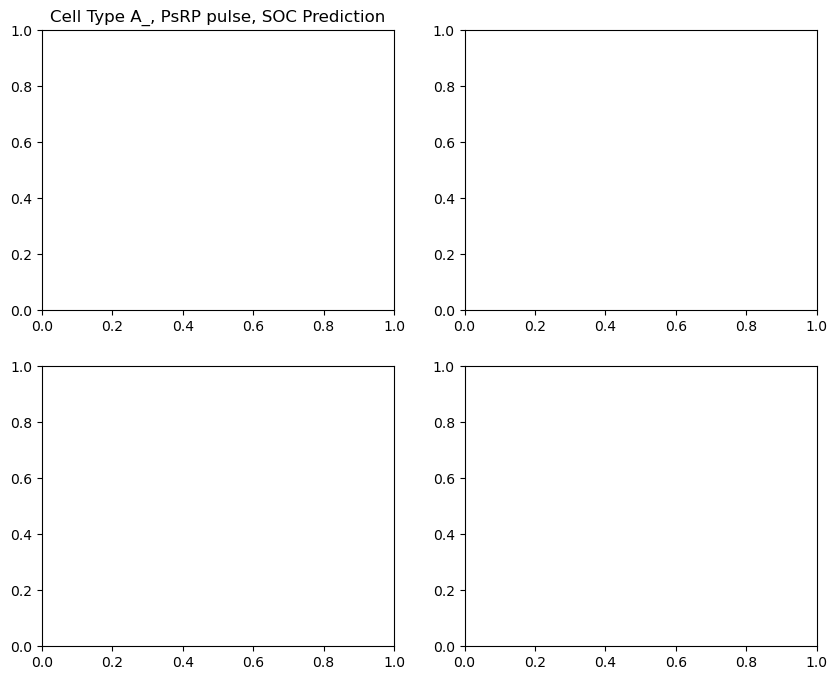

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax = ax.flatten()

hdf = pd.HDFStore("../../data/data_partial_charge_for_ml.h5", mode="r")
df_all = hdf.get("PsRP_2_C/2")

for i, (cell_type, model_state) in enumerate(zip(["A_", "B_", "C_", "D_"], [
    A_rnn_psrp_soc, B_rnn_psrp_soc, C_rnn_psrp_soc, D_rnn_psrp_soc
])):
    df = df_all[df_all["cell_id"].str.startswith(cell_type)].reset_index(drop=True)

    splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    df = df.groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    idx_train, idx_test = next(splitter.split(df, groups=df["measurement_id"]))
    df_train = df.iloc[idx_train].reset_index(drop=True)
    df_test = df.iloc[idx_test].reset_index(drop=True)

    ax[i].set_title(f"Cell Type {cell_type}, PsRP pulse, SOC Prediction")
    test_dataloader = DataLoader(DataFrameDataset(df_test, target="soc_mean", transform=ToTensor()), batch_size=64, shuffle=False)

    model = BasicRNN(input_size= 3, hidden_size=512, output_size=1)
    model.load_state_dict(model_state)
    model.eval()
    with torch.no_grad():
        for X, y in test_dataloader:
            outputs = model(X)
            ax[i].scatter(y.numpy(), outputs.numpy(), alpha=0.5)
            ax[i].set_xlabel("True SOC")
            ax[i].set_ylabel("Predicted SOC")

fig.tight_layout()

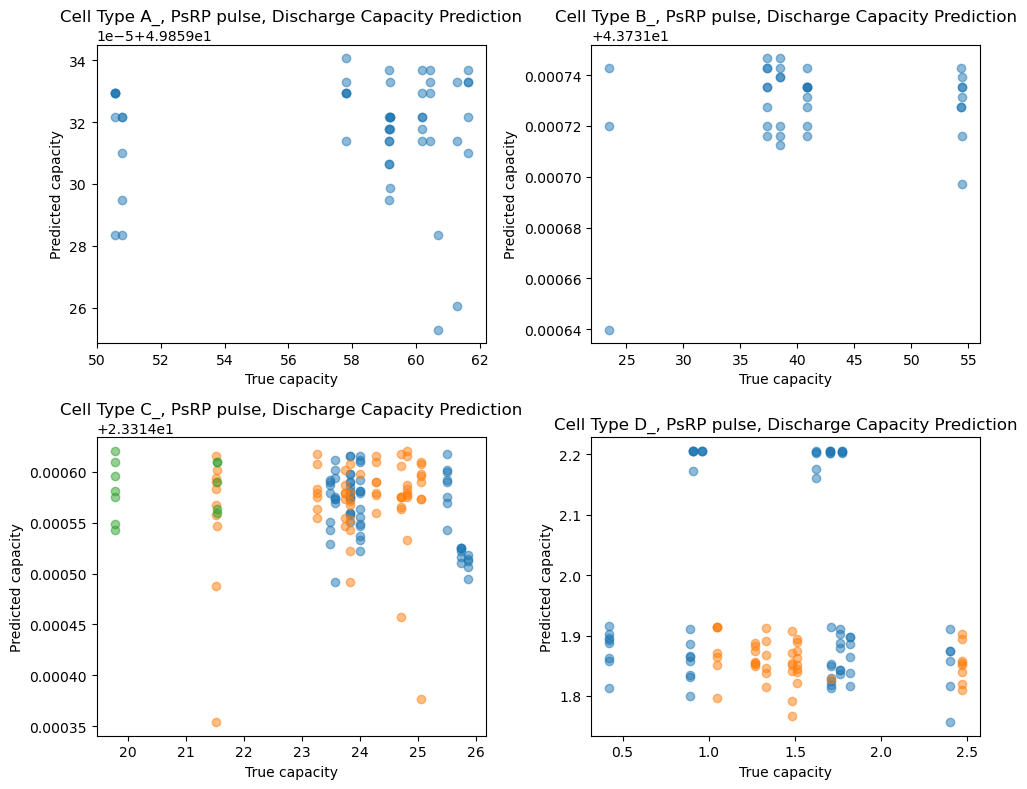

In [45]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax = ax.flatten()

hdf = pd.HDFStore("../../data/data_partial_charge_for_ml.h5", mode="r")
df_all = hdf.get("PsRP_2_C/2")

for i, (cell_type, model_state) in enumerate(zip(["A_", "B_", "C_", "D_"], [
    A_rnn_psrp_discharge, B_rnn_psrp_discharge, C_rnn_psrp_discharge, D_rnn_psrp_discharge
])):
    df = df_all[df_all["cell_id"].str.startswith(cell_type)].reset_index(drop=True)

    splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    df = df.groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    idx_train, idx_test = next(splitter.split(df, groups=df["measurement_id"]))
    df_train = df.iloc[idx_train].reset_index(drop=True)
    df_test = df.iloc[idx_test].reset_index(drop=True)

    ax[i].set_title(f"Cell Type {cell_type}, PsRP pulse, Discharge Capacity Prediction")
    test_dataloader = DataLoader(DataFrameDataset(df_test, target="C/3 discharge capacity", transform=ToTensor()), batch_size=64, shuffle=False)

    model = BasicRNN(input_size= 3, hidden_size=512, output_size=1)
    model.load_state_dict(model_state)
    model.eval()
    with torch.no_grad():
        for X, y in test_dataloader:
            outputs = model(X)
            ax[i].scatter(y.numpy(), outputs.numpy(), alpha=0.5)
            ax[i].set_xlabel("True capacity")
            ax[i].set_ylabel("Predicted capacity")

fig.tight_layout()

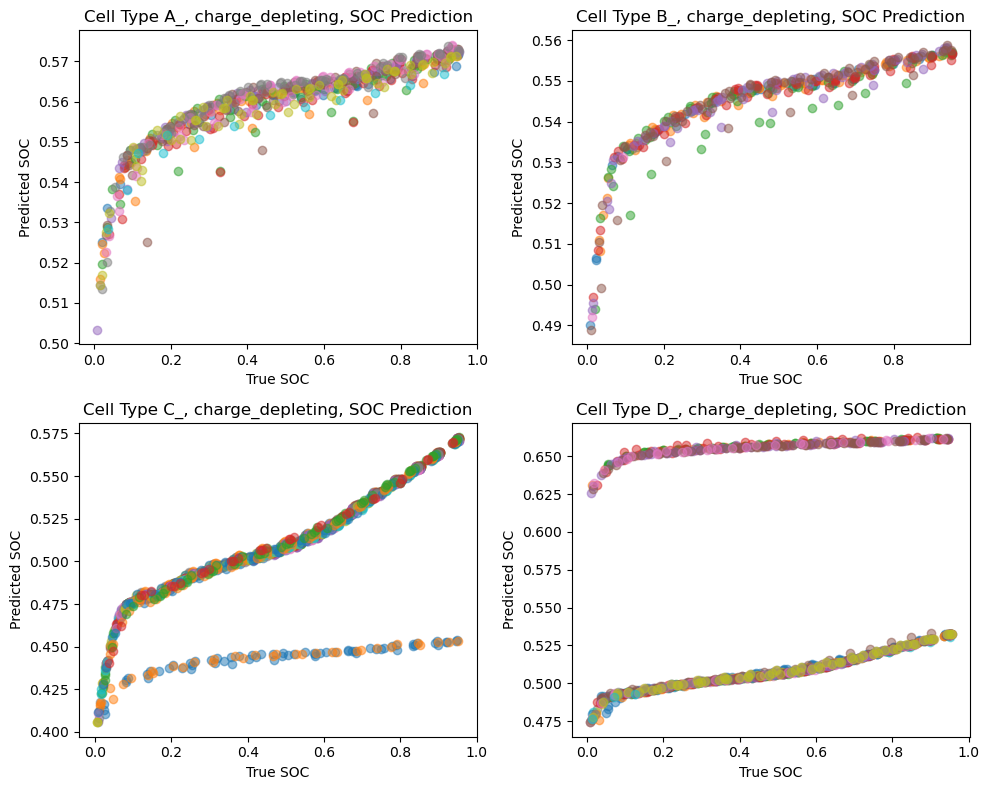

In [44]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax = ax.flatten()

hdf = pd.HDFStore("../../data/data_partial_charge_for_ml.h5", mode="r")
df_all = hdf.get("Charge_Depleting")

for i, (cell_type, model_state) in enumerate(zip(["A_", "B_", "C_", "D_"], [
    A_rnn_charge_depleting_soc, B_rnn_charge_depleting_soc, C_rnn_charge_depleting_soc, D_rnn_charge_depleting_soc
])):
    df = df_all[df_all["cell_id"].str.startswith(cell_type)].reset_index(drop=True)

    # splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    # df = df.groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    # idx_train, idx_test = next(splitter.split(df, groups=df["measurement_id"]))
    # df_train = df.iloc[idx_train].reset_index(drop=True)
    # df_test = df.iloc[idx_test].reset_index(drop=True)

    df_train = df[df["split_type"] == "training"].reset_index(drop=True).groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    df_test = df[df["split_type"] == "testing"].reset_index(drop=True)

    ax[i].set_title(f"Cell Type {cell_type}, charge_depleting, SOC Prediction")
    test_dataloader = DataLoader(DataFrameDataset(df_test, target="soc_mean", transform=ToTensor()), batch_size=64, shuffle=False)

    model = BasicRNN(input_size= 3, hidden_size=512, output_size=1)
    model.load_state_dict(model_state)
    model.eval()
    with torch.no_grad():
        for X, y in test_dataloader:
            outputs = model(X)
            ax[i].scatter(y.numpy(), outputs.numpy(), alpha=0.5)
            ax[i].set_xlabel("True SOC")
            ax[i].set_ylabel("Predicted SOC")

fig.tight_layout()

RuntimeError: Error(s) in loading state_dict for BasicRNN:
	Missing key(s) in state_dict: "rnn.weight_ih_l1", "rnn.weight_hh_l1", "rnn.bias_ih_l1", "rnn.bias_hh_l1". 

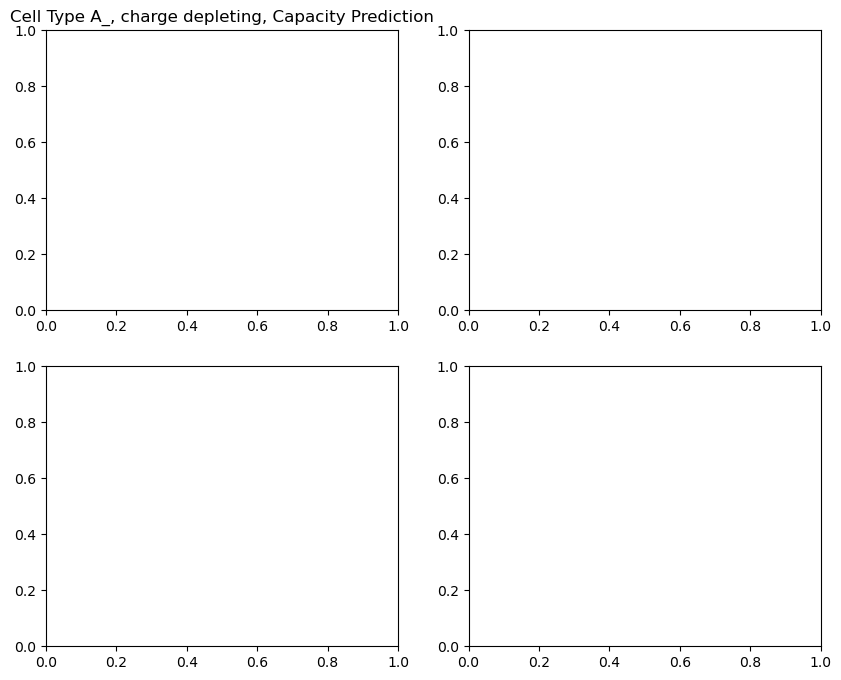

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax = ax.flatten()

hdf = pd.HDFStore("../../data/data_partial_charge_for_ml.h5", mode="r")
df_all = hdf.get("Charge_Depleting")

for i, (cell_type, model_state) in enumerate(zip(["A_", "B_", "C_", "D_"], [
    A_rnn_charge_depleting_capacity, B_rnn_charge_depleting_capacity, C_rnn_charge_depleting_capacity, D_rnn_charge_depleting_capacity
])):
    df = df_all[df_all["cell_id"].str.startswith(cell_type)].reset_index(drop=True)

    # splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    # df = df.groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    # idx_train, idx_test = next(splitter.split(df, groups=df["measurement_id"]))
    # df_train = df.iloc[idx_train].reset_index(drop=True)
    # df_test = df.iloc[idx_test].reset_index(drop=True)

    df_train = df[df["split_type"] == "training"].reset_index(drop=True).groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    df_test = df[df["split_type"] == "testing"].reset_index(drop=True)

    ax[i].set_title(f"Cell Type {cell_type}, charge depleting, Capacity Prediction")
    test_dataloader = DataLoader(DataFrameDataset(df_test, target="C/3 discharge capacity", transform=ToTensor()), batch_size=64, shuffle=False)

    model = BasicRNN(input_size= 3, hidden_size=512, output_size=1)
    model.load_state_dict(model_state)
    model.eval()
    with torch.no_grad():
        for X, y in test_dataloader:
            outputs = model(X)
            ax[i].scatter(y.numpy(), outputs.numpy(), alpha=0.5)
            ax[i].set_xlabel("True capacity")
            ax[i].set_ylabel("Predicted capacity")

fig.tight_layout()

RuntimeError: Error(s) in loading state_dict for BasicRNN:
	Missing key(s) in state_dict: "rnn.weight_ih_l1", "rnn.weight_hh_l1", "rnn.bias_ih_l1", "rnn.bias_hh_l1". 

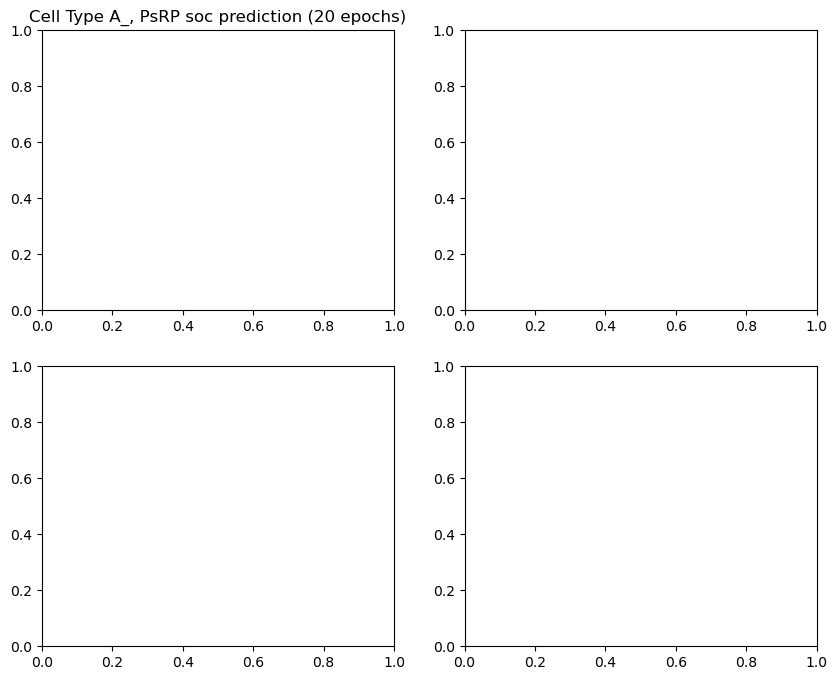

In [ ]:
A_20 = torch.load('../../results/neural_network/rnn/PsRP_2_C2_soc_mean_A_model_20.pth')
B_20 = torch.load('../../results/neural_network/rnn/PsRP_2_C2_soc_mean_B_model_20.pth')
C_20 = torch.load('../../results/neural_network/rnn/PsRP_2_C2_soc_mean_C_model_20.pth')
D_20 = torch.load('../../results/neural_network/rnn/PsRP_2_C2_soc_mean_D_model_20.pth')

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax = ax.flatten()
hdf = pd.HDFStore("../../data/data_partial_charge_for_ml_fixed.h5", mode="r")
df_all = hdf.get("PsRP_2_C/2")

for i, (cell_type, model_state) in enumerate(zip(["A_", "B_", "C_", "D_"], [
    A_20, B_20, C_20, D_20
])):
    df = df_all[df_all["cell_id"].str.startswith(cell_type)].reset_index(drop=True)

    splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    df = df.groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    idx_train, idx_test = next(splitter.split(df, groups=df["measurement_id"]))
    df_train = df.iloc[idx_train].reset_index(drop=True)
    df_test = df.iloc[idx_test].reset_index(drop=True)

    ax[i].set_title(f"Cell Type {cell_type}, PsRP soc prediction (20 epochs)")
    test_dataloader = DataLoader(DataFrameDataset(df_test, target="soc_mean", transform=ToTensor()), batch_size=64, shuffle=False)

    model = BasicRNN(input_size= 3, hidden_size=512, output_size=1)
    model.load_state_dict(model_state)
    model.eval()
    with torch.no_grad():
        for X, y in test_dataloader:
            outputs = model(X)
            ax[i].scatter(y.numpy(), outputs.numpy(), alpha=0.5)
            ax[i].set_xlabel("True capacity")
            ax[i].set_ylabel("Predicted capacity")

fig.tight_layout()

In [3]:
class BasicRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2):
        super(BasicRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Set initial hidden and cell states 
        h0 = torch.zeros(2, x.size(0), self.rnn.hidden_size).to(x.device)
        
        # Forward propagate RNN
        out, _ = self.rnn(x , h0)  # out: tensor of shape (batch_size, seq_length, hidden_size)
        
        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out
    
class DataFrameDataset(Dataset):
    # def __init__(self, h5_path, key, target, transform=None):
    def __init__(self, dataframe, target, transform=None):
        # self.h5_path = h5_path
        # self.key = key
        # self.data_cache = pd.HDFStore(self.h5_path)
        # self.data = self.data_cache[self.key]
        self.data = dataframe
        self.transform = transform
        self.targets = self.data[target]
        # if self.data['voltage_0.0s'].isna().any():
        #     self.data = self.data.drop(['voltage_0.0s', 'current_0.0s', 'power_0.0s'], axis=1).reset_index(drop=True)
        #     self.targets = self.data[target].reset_index(drop=True)

        self.voltage_min = self.data.filter(regex="voltage").min().min()
        self.voltage_max = self.data.filter(regex="voltage").max().max()
        self.current_min = self.data.filter(regex="current").min().min()
        self.current_max = self.data.filter(regex="current").max().max()
        self.power_min = self.data.filter(regex="power").min().min()
        self.power_max = self.data.filter(regex="power").max().max()


    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data.iloc[idx]
        sample = sample.filter(regex="voltage|current|power")

        length = int(len(sample)/3)
        sample = sample.values.reshape((length, 3))  # reshape to (seq_length, num_features)

        target = self.targets.iloc[idx]
        if self.transform:
            sample = self.transform(sample)
        return sample, target.astype("float32")
class ToTensor(object): 
    """Convert pandas dataframe sample to tensor."""
    def __call__(self, sample):
        return torch.tensor([sample[0], sample[1], sample[2]], dtype=torch.float)

C:\Users\etenney\AppData\Local\Temp\1\ipykernel_24456\552325608.py:57: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  return torch.tensor([sample[0], sample[1], sample[2]], dtype=torch.float)


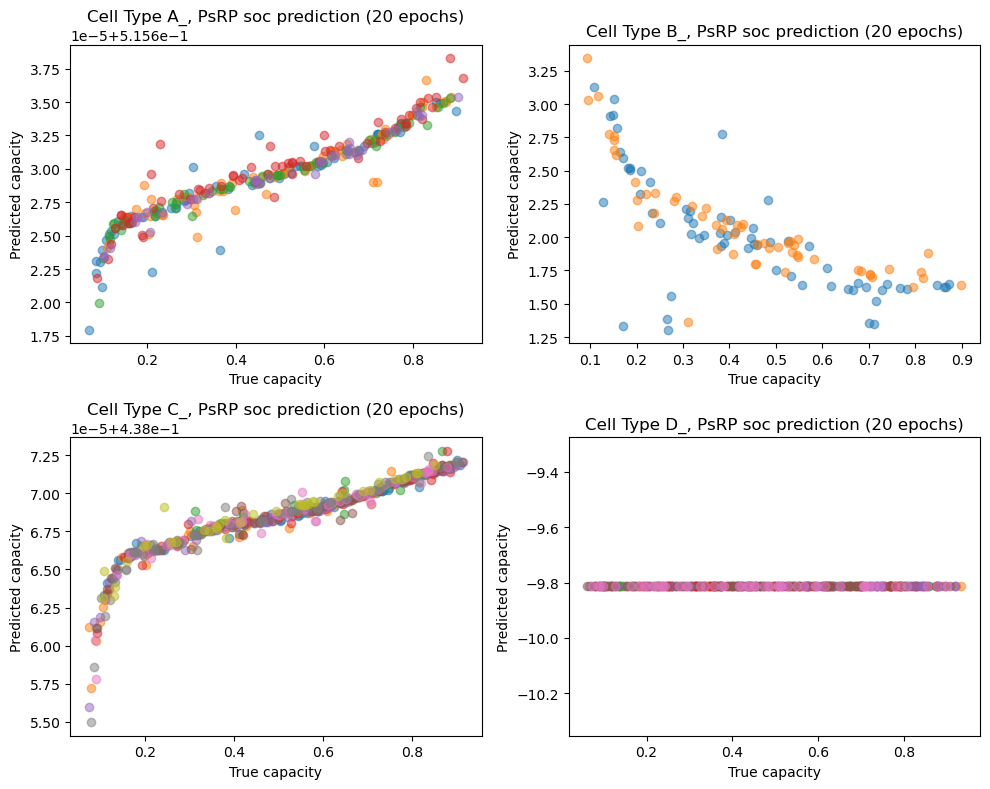

In [5]:
A_fixed = torch.load('../../results/neural_network/rnn/PsRP_2_C2_soc_mean_A_model_fixed.pth')
B_fixed = torch.load('../../results/neural_network/rnn/PsRP_2_C2_soc_mean_B_model_fixed.pth')
C_fixed = torch.load('../../results/neural_network/rnn/PsRP_2_C2_soc_mean_C_model_fixed.pth')
D_fixed = torch.load('../../results/neural_network/rnn/PsRP_2_C2_soc_mean_D_model_fixed.pth')

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax = ax.flatten()
hdf = pd.HDFStore("../../data/data_partial_charge_for_ml_fixed.h5", mode="r")
df_all = hdf.get("PsRP_2_C/2")

for i, (cell_type, model_state) in enumerate(zip(["A_", "B_", "C_", "D_"], [
    A_fixed, B_fixed, C_fixed, D_fixed
])):
    df = df_all[df_all["cell_id"].str.startswith(cell_type)].reset_index(drop=True)

    splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    df = df.groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    idx_train, idx_test = next(splitter.split(df, groups=df["measurement_id"]))
    df_train = df.iloc[idx_train].reset_index(drop=True)
    df_test = df.iloc[idx_test].reset_index(drop=True)

    ax[i].set_title(f"Cell Type {cell_type}, PsRP soc prediction (20 epochs)")
    test_dataloader = DataLoader(DataFrameDataset(df_train, target="soc_mean", transform=ToTensor()), batch_size=64, shuffle=False)

    model = BasicRNN(input_size=3, hidden_size=512, output_size=1)
    model.load_state_dict(model_state)
    model.eval()
    with torch.no_grad():
        for X, y in test_dataloader:
            outputs = model(X)
            ax[i].scatter(y.numpy(), outputs.numpy(), alpha=0.5)
            ax[i].set_xlabel("True capacity")
            ax[i].set_ylabel("Predicted capacity")
            # ax[i].set_ylim(0, 1)
            # ax[i].draw()

fig.tight_layout()

In [ ]:
df = df_all[df_all["cell_id"].str.startswith("A_")].reset_index(drop=True)

splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
df = df.groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
idx_train, idx_test = next(splitter.split(df, groups=df["measurement_id"]))

df_train = df.iloc[idx_train].reset_index(drop=True)
df_test = df.iloc[idx_test].reset_index(drop=True)

sample = df_train.iloc[0].filter(regex="voltage|current|power")

sample = sample.values.reshape((int(len(sample)/3), 3))  # reshape to (seq_length, num_features)
# sample = sample.values.reshape((3, int(len(sample)/3)))  # reshape to (num_features, seq_length)

sample.shape
sample_tensor = torch.tensor([sample[:, 0], sample[:, 1], sample[:, 2]], dtype=torch.float)
# sample_tensor = torch.tensor([sample[0], sample[1], sample[2]], dtype=torch.float)

sample.shape
A_depleting_fixed = torch.load('../../results/neural_network/rnn/Charge_Depleting_soc_mean_A_model_fixed.pth')
B_depleting_fixed = torch.load('../../results/neural_network/rnn/Charge_Depleting_soc_mean_B_model_fixed.pth')
C_depleting_fixed = torch.load('../../results/neural_network/rnn/Charge_Depleting_soc_mean_C_model_fixed.pth')
# D_fixed = torch.load('../../results/neural_network/rnn/PsRP_2_C2_soc_mean_D_model_fixed.pth')

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax = ax.flatten()
df_all = hdf.get("Charge_Depleting")

for i, (cell_type, model_state) in enumerate(zip(["A_", "B_", "C_"], [
    A_depleting_fixed, B_depleting_fixed, C_depleting_fixed
])):
    df = df_all[df_all["cell_id"].str.startswith(cell_type)].reset_index(drop=True)

    # splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    # df = df.groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    # idx_train, idx_test = next(splitter.split(df, groups=df["measurement_id"]))
    # df_train = df.iloc[idx_train].reset_index(drop=True)
    # df_test = df.iloc[idx_test].reset_index(drop=True)
    df_train = df[df["split_type"] == "training"].reset_index(drop=True).groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    df_test = df[df["split_type"] == "testing"].reset_index(drop=True)

    ax[i].set_title(f"Cell Type {cell_type}, charge depleting soc prediction (5 epochs)")
    test_dataloader = DataLoader(DataFrameDataset(df_train, target="soc_mean", transform=ToTensor()), batch_size=64, shuffle=False)

    model = BasicRNN(input_size= 3, hidden_size=512, output_size=1)
    model.load_state_dict(model_state)
    model.eval()
    with torch.no_grad():
        for X, y in test_dataloader:
            outputs = model(X)
            ax[i].scatter(y.numpy(), outputs.numpy(), alpha=0.5)
            ax[i].set_xlabel("True soc")
            ax[i].set_ylabel("Predicted soc")
            # ax[i].set_ylim(0, 1)
            # ax[i].draw()

fig.tight_layout()

(900, 3)

C:\Users\etenney\AppData\Local\Temp\1\ipykernel_24468\222936475.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', 100)
C:\Users\etenney\AppData\Local\Temp\1\ipykernel_24468\222936475.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


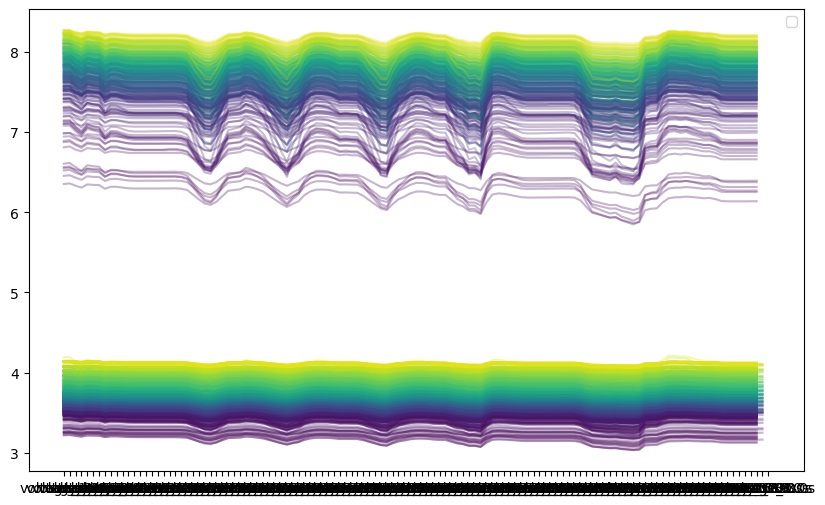

In [99]:
df = df_all[df_all["cell_id"].str.startswith("D")].reset_index(drop=True)

df_train = df[df["split_type"] == "training"].reset_index(drop=True).groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
df_test = df[df["split_type"] == "testing"].reset_index(drop=True)

# sample = df_train.iloc[0].filter(regex="voltage|current|power")

import matplotlib.cm as cm
cmap = cm.get_cmap('viridis', 100)
fig, ax = plt.subplots(figsize=(10, 6))
for i, row in df_test.iterrows():
    sample = row.filter(regex="voltage")
    ax.plot(sample.index, sample.values, alpha=0.3, color=cmap(row['soc_mean']))
ax.legend()

In [105]:
df[df["voltage_1.0s"] > 5]

,temperature,soc_mean,soc_initial,soc_final,split_type,voltage_1.0s,voltage_2.0s,voltage_3.0s,voltage_4.0s,voltage_5.0s,...,Charge depleting cycle charge throughput,Charge sustaining cycle charge efficiency,Post C/10 charge relaxation fit MSE,Post C/5 charge relaxation fit MSE,Post C/3 charge relaxation fit MSE,Post P/3 charge relaxation fit MSE,Post C/2 charge relaxation fit MSE,Post 1C charge relaxation fit MSE,Thickness growth,Volume growth
4539,30.833333,0.921143,0.923768,0.917412,testing,8.224,8.225,8.178,8.140,8.193,...,2.263195,1.284951,0.000002,0.000002,0.000002,0.000002,0.000617,0.000580,NaN,NaN
4540,30.900000,0.837541,0.840188,0.833778,testing,8.150,8.151,8.104,8.066,8.119,...,2.263195,1.284951,0.000002,0.000002,0.000002,0.000002,0.000617,0.000580,NaN,NaN
4541,30.766667,0.753319,0.755982,0.749533,testing,8.099,8.100,8.053,8.015,8.068,...,2.263195,1.284951,0.000002,0.000002,0.000002,0.000002,0.000617,0.000580,NaN,NaN
4542,30.750000,0.668595,0.671276,0.664785,testing,8.053,8.054,8.006,7.968,8.022,...,2.263195,1.284951,0.000002,0.000002,0.000002,0.000002,0.000617,0.000580,NaN,NaN
4543,30.845833,0.583305,0.586006,0.579466,testing,7.998,7.999,7.952,7.914,7.968,...,2.263195,1.284951,0.000002,0.000002,0.000002,0.000002,0.000617,0.000580,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20956,32.500000,0.074112,0.086993,0.063691,training,6.901,6.881,6.867,6.895,6.855,...,2.906750,1.303486,0.000004,0.000004,0.000004,0.000004,0.001878,0.001354,NaN,NaN
20957,32.500000,0.090431,0.097109,0.086301,training,6.910,6.944,7.046,7.149,7.146,...,2.906750,1.303486,0.000004,0.000004,0.000004,0.000004,0.001878,0.001354,NaN,NaN
20958,32.500000,0.081066,0.085285,0.070584,training,6.786,6.874,6.889,6.963,7.130,...,2.906750,1.303486,0.000004,0.000004,0.000004,0.000004,0.001878,0.001354,NaN,NaN
20959,32.500000,0.063412,0.074352,0.051404,training,6.798,6.874,6.848,6.940,6.838,...,2.906750,1.303486,0.000004,0.000004,0.000004,0.000004,0.001878,0.001354,NaN,NaN


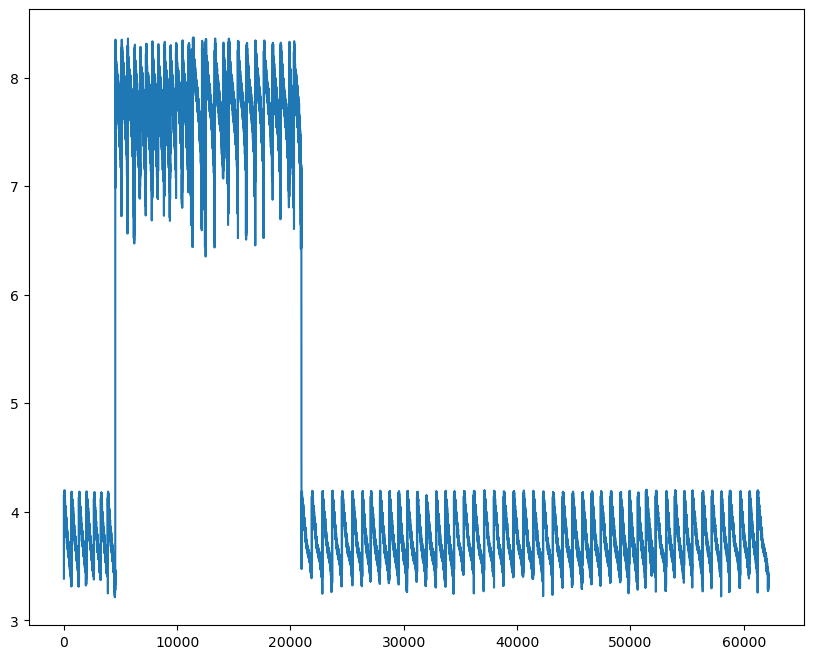

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(range(62169), df['voltage_1.0s'])

C:\Users\etenney\AppData\Local\Temp\1\ipykernel_37136\1096567881.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', 100)
C:\Users\etenney\AppData\Local\Temp\1\ipykernel_37136\1096567881.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


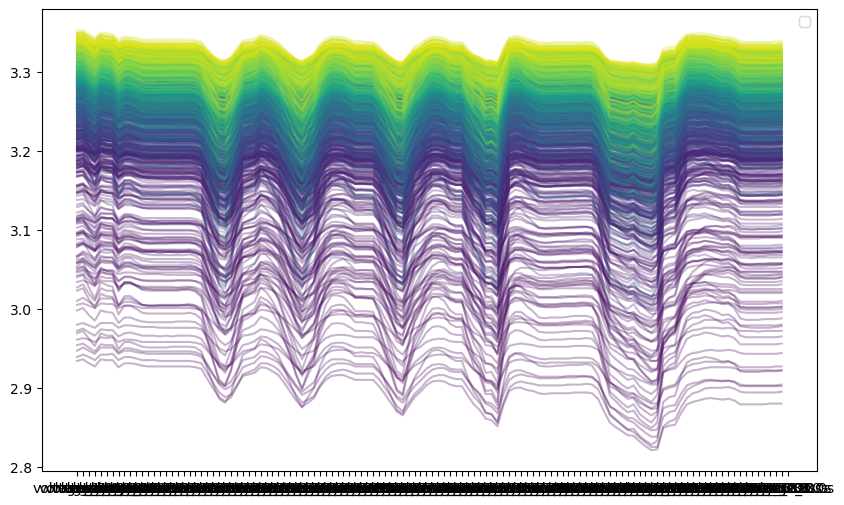

In [2]:
hdf = pd.HDFStore("../../data/data_partial_charge_for_ml_fixed.h5", mode="r")

df_all_fixed = hdf.get("Charge_Depleting")
df = df_all_fixed[df_all_fixed["cell_id"].str.startswith("D")].reset_index(drop=True)

df_train = df[df["split_type"] == "training"].reset_index(drop=True).groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
df_test = df[df["split_type"] == "testing"].reset_index(drop=True)

# sample = df_train.iloc[0].filter(regex="voltage|current|power")

import matplotlib.cm as cm
cmap = cm.get_cmap('viridis', 100)
fig, ax = plt.subplots(figsize=(10, 6))
for i, row in df_test.iterrows():
    sample = row.filter(regex="voltage")
    ax.plot(sample.index, sample.values, alpha=0.3, color=cmap(row['soc_mean']))
ax.legend()

In [4]:
df_all_fixed['cell_id'].unique()

array(['B_01', 'B_02', 'B_03', 'B_04', 'B_05', 'B_06', 'B_07', 'B_08',
       'A_24', 'A_06', 'A_10', 'A_11', 'A_15', 'A_21', 'A_22', 'A_02',
       'A_03', 'A_04', 'A_20', 'A_05', 'A_13', 'A_17', 'A_19', 'A_23',
       'C_01', 'C_02', 'C_03', 'C_04', 'C_TX_04', 'C_TX_05', 'C_TX_11',
       'C_TX_13', 'C_TX_14', 'C_TX_32', 'C_TX_37', 'C_TX_43', 'C_TX_48',
       'C_TX_63', 'C_TX_66', 'C_TX_74', 'C_TX_64', 'C_NY_03', 'C_NY_08',
       'C_NY_28', 'C_NY_66', 'D_01', 'D_03', 'D_05', 'D_06', 'D_07',
       'D_08', 'D_09', 'D_11', 'D_12', 'D_14', 'D_15', 'D_04', 'D_10',
       'D_13', 'D_02', 'D_19', 'D_16', 'D_17', 'D_18', 'D_20', 'D_21',
       'D_22', 'D_23', 'D_24', 'D_25', 'D_26', 'D_27', 'D_28', 'D_29',
       'D_30'], dtype=object)

In [9]:
df_all_fixed[df_all_fixed['cell_id'] == 'B_01']['measurement_id'].unique()

array([178, 181, 184, 187])

In [6]:
hdf = pd.HDFStore("../../data/data_raw.h5", mode="r")
keys = hdf.keys()
keys

['/D/data_240624_ReCellML_A123_Cell01_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell03_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell05_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell06_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell07_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell08_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell09_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell11_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell12_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell14_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell15_charac_30C',
 '/D/data_240626_ReCellML_A123_Cell04_charac_30C',
 '/D/data_240626_ReCellML_A123_Cell10_charac_30C',
 '/D/data_240628_ReCellML_A123_Cell13_charac_30C',
 '/D/data_240709_ReCellML_A123_cell01_charac_45oC',
 '/D/data_240709_ReCellML_A123_cell02_charac_45oC',
 '/D/data_240709_ReCellML_A123_cell03_charac_45oC',
 '/D/data_240709_ReCellML_A123_cell04_charac_45oC',
 '/D/data_240709_ReCellML_A123_cell05_charac_45oC',
 '/D/data_240709_ReCellML_

In [32]:
class BasicRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2):
        super(BasicRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Set initial hidden and cell states 
        h0 = torch.zeros(2, x.size(0), self.rnn.hidden_size).to(x.device)
        
        # Forward propagate RNN
        out, _ = self.rnn(x , h0)  # out: tensor of shape (batch_size, seq_length, hidden_size)
        
        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out

class DataFrameDataset(Dataset):
    # def __init__(self, h5_path, key, target, transform=None):
    def __init__(self, dataframe, target, transform=None):
        # self.h5_path = h5_path
        # self.key = key
        # self.data_cache = pd.HDFStore(self.h5_path)
        # self.data = self.data_cache[self.key]
        self.data = dataframe
        self.transform = transform
        self.targets = self.data[target]
        if self.data['voltage_0.0s'].isna().any():
            self.data = self.data.drop(['voltage_0.0s', 'current_0.0s', 'power_0.0s'], axis=1).reset_index(drop=True)
            self.targets = self.data[target].reset_index(drop=True)

        self.voltage_min = self.data.filter(regex="voltage").min().min()
        self.voltage_max = self.data.filter(regex="voltage").max().max()
        self.current_min = self.data.filter(regex="current").min().min()
        self.current_max = self.data.filter(regex="current").max().max()
        self.power_min = self.data.filter(regex="power").min().min()
        self.power_max = self.data.filter(regex="power").max().max()

        self.target_min = self.targets.min()
        self.target_max = self.targets.max()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data.iloc[idx]
        sample = sample.filter(regex="voltage|current|power")

        length = int(len(sample)/3)
        sample = sample.values.reshape((length, 3))  #reshape to (seq_length, num_features)
        # sample = sample.values.reshape((3, length))  # reshape to (num_features, seq_length)
        sample[:, 0] = (sample[:, 0] - self.voltage_min) / (self.voltage_max - self.voltage_min)
        sample[:, 1] = (sample[:, 1] - self.current_min) / (self.current_max - self.current_min)
        sample[:, 2] = (sample[:, 2] - self.power_min) / (self.power_max - self.power_min)
        # sample[0] = (sample[0] - self.voltage_min) / (self.voltage_max - self.voltage_min)
        # sample[1] = (sample[1] - self.current_min) / (self.current_max - self.current_min)
        # sample[2] = (sample[2] - self.power_min) / (self.power_max - self.power_min)

        target = self.targets.iloc[idx]
        target = (target - self.target_min) / (self.target_max - self.target_min)
        if self.transform:
            sample = self.transform(sample)
        return sample, target.astype("float32")

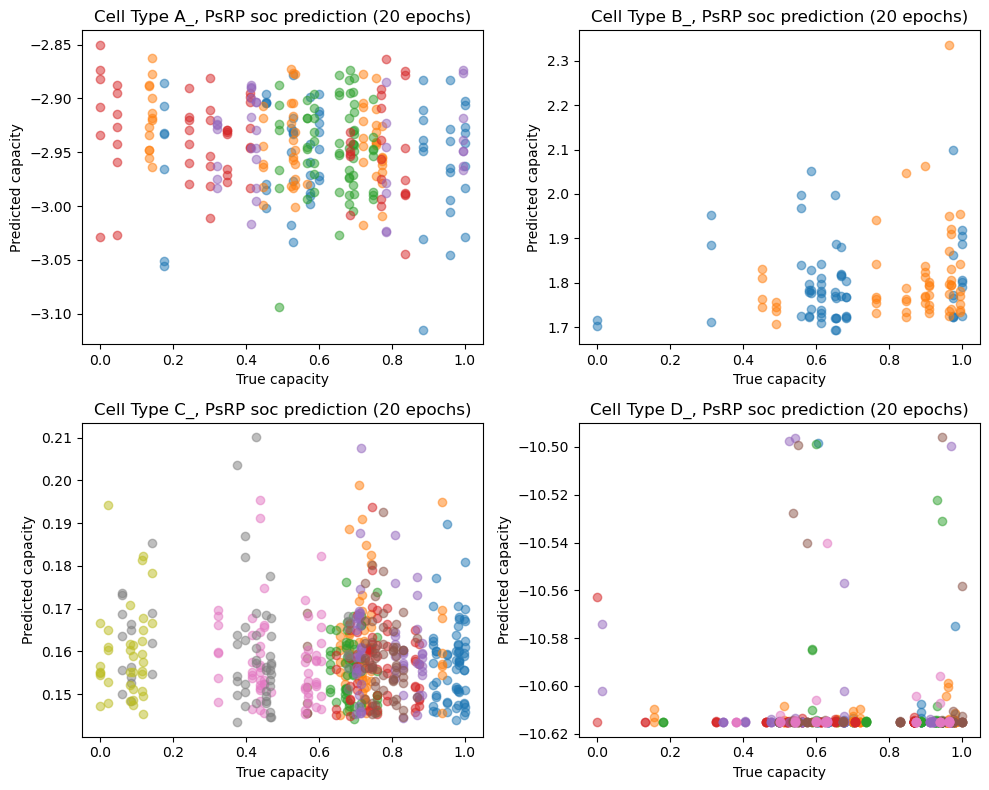

In [15]:
A_fixed_discharge = torch.load('../../results/neural_network/rnn/PsRP_2_C2_C3 discharge capacity_A_model_fixed.pth')
B_fixed_discharge = torch.load('../../results/neural_network/rnn/PsRP_2_C2_C3 discharge capacity_B_model_fixed.pth')
C_fixed_discharge = torch.load('../../results/neural_network/rnn/PsRP_2_C2_C3 discharge capacity_C_model_fixed.pth')
D_fixed_discharge = torch.load('../../results/neural_network/rnn/PsRP_2_C2_C3 discharge capacity_D_model_fixed.pth')

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax = ax.flatten()
df_all = hdf.get("PsRP_2_C/2")

for i, (cell_type, model_state) in enumerate(zip(["A_", "B_", "C_", "D_"], [
    A_fixed_discharge, B_fixed_discharge, C_fixed_discharge, D_fixed_discharge
])):
    df = df_all[df_all["cell_id"].str.startswith(cell_type)].reset_index(drop=True)

    splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    df = df.groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    idx_train, idx_test = next(splitter.split(df, groups=df["measurement_id"]))
    df_train = df.iloc[idx_train].reset_index(drop=True)
    df_test = df.iloc[idx_test].reset_index(drop=True)

    ax[i].set_title(f"Cell Type {cell_type}, PsRP soc prediction (20 epochs)")
    test_dataloader = DataLoader(DataFrameDataset(df_train, target="C/3 discharge capacity", transform=ToTensor()), batch_size=64, shuffle=False)

    model = BasicRNN(input_size=3, hidden_size=512, output_size=1)
    model.load_state_dict(model_state)
    model.eval()
    with torch.no_grad():
        for X, y in test_dataloader:
            outputs = model(X)
            ax[i].scatter(y.numpy(), outputs.numpy(), alpha=0.5)
            ax[i].set_xlabel("True capacity")
            ax[i].set_ylabel("Predicted capacity")
            # ax[i].set_ylim(0, 1)
            # ax[i].draw()

fig.tight_layout()

# OVERFIT TESTING

Given a random sample of only 5 inputs, can our model actually overfit these?

[57, 12, 140, 125, 114]
[81, 14, 3, 94, 35]
[114, 25, 281, 250, 228]
[327, 57, 12, 379, 140]


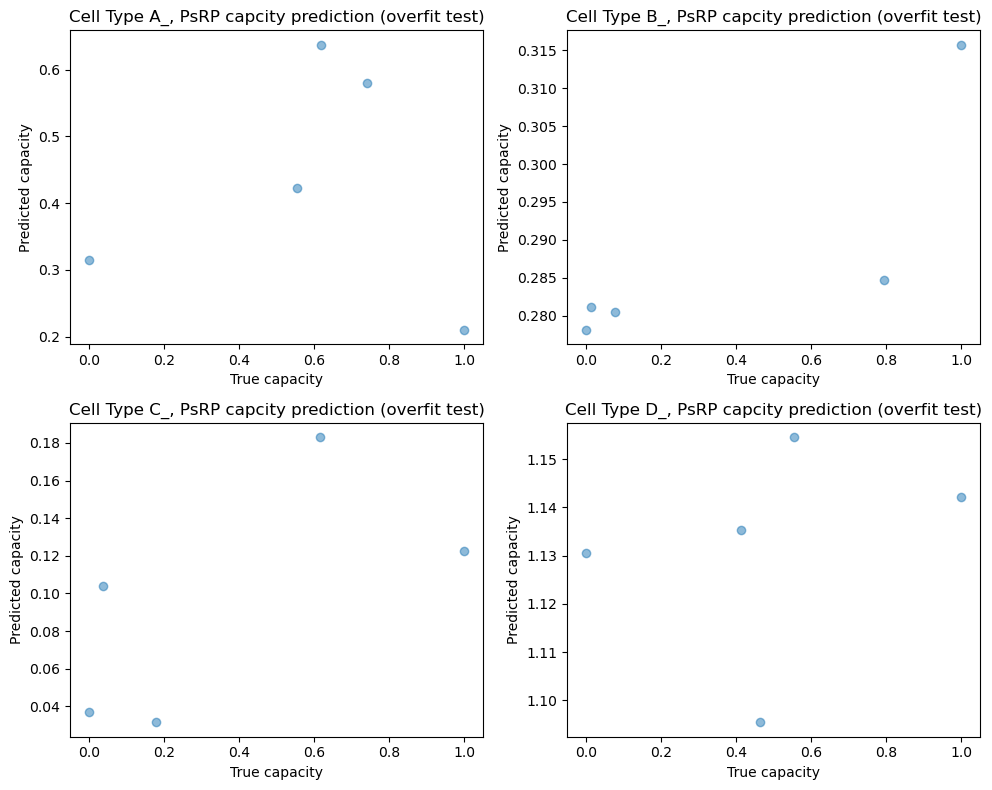

In [ ]:
A_overfit = torch.load('../../results/neural_network/overfit_testing/PsRP_2_C2_C3 discharge capacity_A_model.pth')
B_overfit = torch.load('../../results/neural_network/overfit_testing/PsRP_2_C2_C3 discharge capacity_B_model.pth')
C_overfit = torch.load('../../results/neural_network/overfit_testing/PsRP_2_C2_C3 discharge capacity_C_model.pth')
D_overfit = torch.load('../../results/neural_network/overfit_testing/PsRP_2_C2_C3 discharge capacity_D_model.pth')
import random

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax = ax.flatten()
df_all = hdf.get("PsRP_2_C/2")

for i, (cell_type, model_state) in enumerate(zip(["A_", "B_", "C_", "D_"], [
    A_overfit, B_overfit, C_overfit, D_overfit
])):
    df = df_all[df_all["cell_id"].str.startswith(cell_type)].reset_index(drop=True)

    splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    df = df.groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    idx_train, idx_test = next(splitter.split(df, groups=df["measurement_id"]))
    df_train = df.iloc[idx_train].reset_index(drop=True)
    df_test = df.iloc[idx_test].reset_index(drop=True)

    random.seed(42)
    overfit_idxs = random.sample(range(len(df_train)), 5)
    df_train = df_train.iloc[overfit_idxs].reset_index(drop=True)
    df_test = df_train.copy().reset_index(drop=True)
    print(overfit_idxs)

    ax[i].set_title(f"Cell Type {cell_type}, PsRP capcity prediction ")
    test_dataloader = DataLoader(DataFrameDataset(df_train, target="C/3 discharge capacity", transform=ToTensor()), batch_size=64, shuffle=False)

    model = BasicRNN(input_size=3, hidden_size=512, output_size=1)
    model.load_state_dict(model_state)
    model.eval()
    with torch.no_grad():
        for X, y in test_dataloader:
            outputs = model(X)
            ax[i].scatter(y.numpy(), outputs.numpy(), alpha=0.5)
            ax[i].set_xlabel("True capacity")
            ax[i].set_ylabel("Predicted capacity")
            # ax[i].set_ylim(0, 1)
            # ax[i].draw()

fig.tight_layout()

[57, 12, 140, 125, 114]
[81, 14, 3, 94, 35]
[114, 25, 281, 250, 228]
[327, 57, 12, 379, 140]


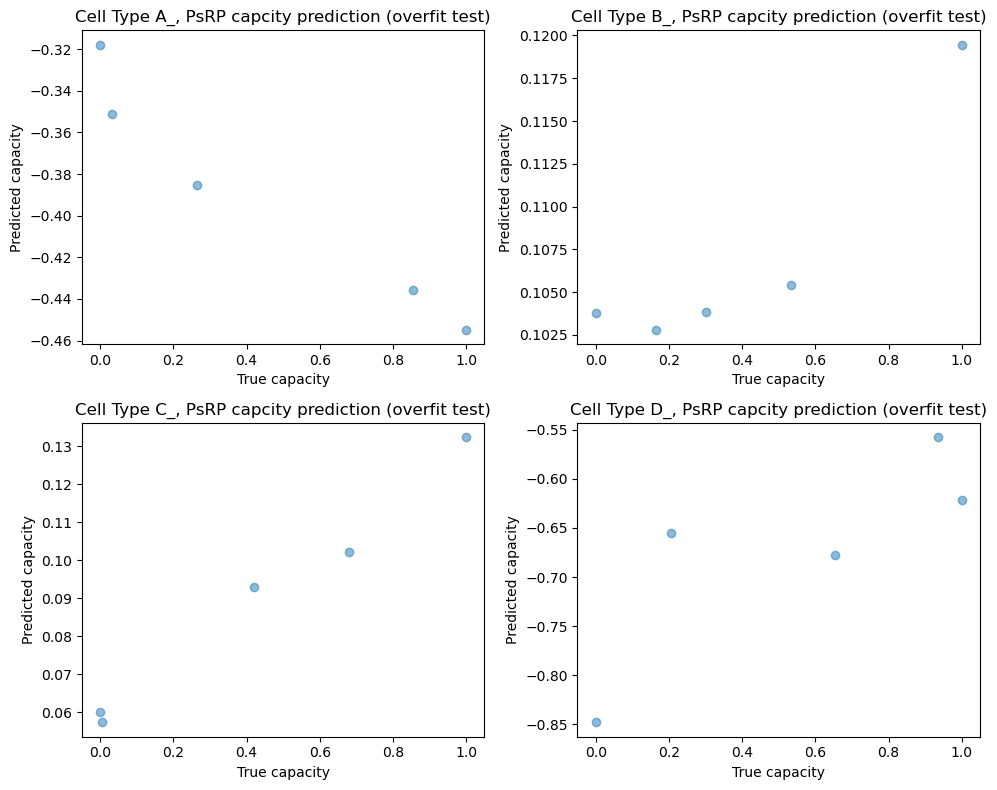

In [25]:
A_overfit = torch.load('../../results/neural_network/overfit_testing/PsRP_2_C2_soc_mean_A_model.pth')
B_overfit = torch.load('../../results/neural_network/overfit_testing/PsRP_2_C2_soc_mean_B_model.pth')
C_overfit = torch.load('../../results/neural_network/overfit_testing/PsRP_2_C2_soc_mean_C_model.pth')
D_overfit = torch.load('../../results/neural_network/overfit_testing/PsRP_2_C2_soc_mean_D_model.pth')

import random

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax = ax.flatten()
df_all = hdf.get("PsRP_2_C/2")

for i, (cell_type, model_state) in enumerate(zip(["A_", "B_", "C_", "D_"], [
    A_overfit, B_overfit, C_overfit, D_overfit
])):
    df = df_all[df_all["cell_id"].str.startswith(cell_type)].reset_index(drop=True)

    splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    df = df.groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    idx_train, idx_test = next(splitter.split(df, groups=df["measurement_id"]))
    df_train = df.iloc[idx_train].reset_index(drop=True)
    df_test = df.iloc[idx_test].reset_index(drop=True)

    random.seed(42)
    overfit_idxs = random.sample(range(len(df_train)), 5)
    df_train = df_train.iloc[overfit_idxs].reset_index(drop=True)
    df_test = df_train.copy().reset_index(drop=True)
    print(overfit_idxs)

    ax[i].set_title(f"Cell Type {cell_type}, PsRP capcity prediction (overfit test)")
    test_dataloader = DataLoader(DataFrameDataset(df_train, target="soc_mean", transform=ToTensor()), batch_size=64, shuffle=False)

    model = BasicRNN(input_size=3, hidden_size=256, output_size=1)
    model.load_state_dict(model_state)
    model.eval()
    with torch.no_grad():
        for X, y in test_dataloader:
            outputs = model(X)
            ax[i].scatter(y.numpy(), outputs.numpy(), alpha=0.5)
            ax[i].set_xlabel("True capacity")
            ax[i].set_ylabel("Predicted capacity")
            # ax[i].set_ylim(0, 1)
            # ax[i].draw()

fig.tight_layout()

[2619, 456, 102, 3037, 1126]
tensor([[0.1800],
        [0.1936],
        [0.1858],
        [0.1982],
        [0.1540]]) tensor([0.5120, 0.0000, 1.0000, 0.8410, 0.7168])
[1309, 228, 51, 1518, 563]
tensor([[0.1586],
        [0.1355],
        [0.1767],
        [0.1878],
        [0.1755]]) tensor([1.0000, 0.2073, 0.3536, 0.0000, 0.2618])
[5238, 912, 204, 6074, 2253]
tensor([[0.1286],
        [0.1193],
        [0.1055],
        [0.1317],
        [0.1284]]) tensor([0.7636, 0.9212, 1.0000, 0.0000, 0.5333])
[5238, 912, 204, 2253, 2006]
tensor([[-0.2439],
        [-0.2060],
        [-0.2493],
        [-0.2491],
        [-0.4093]]) tensor([0.5211, 0.0000, 0.5282, 0.9930, 1.0000])


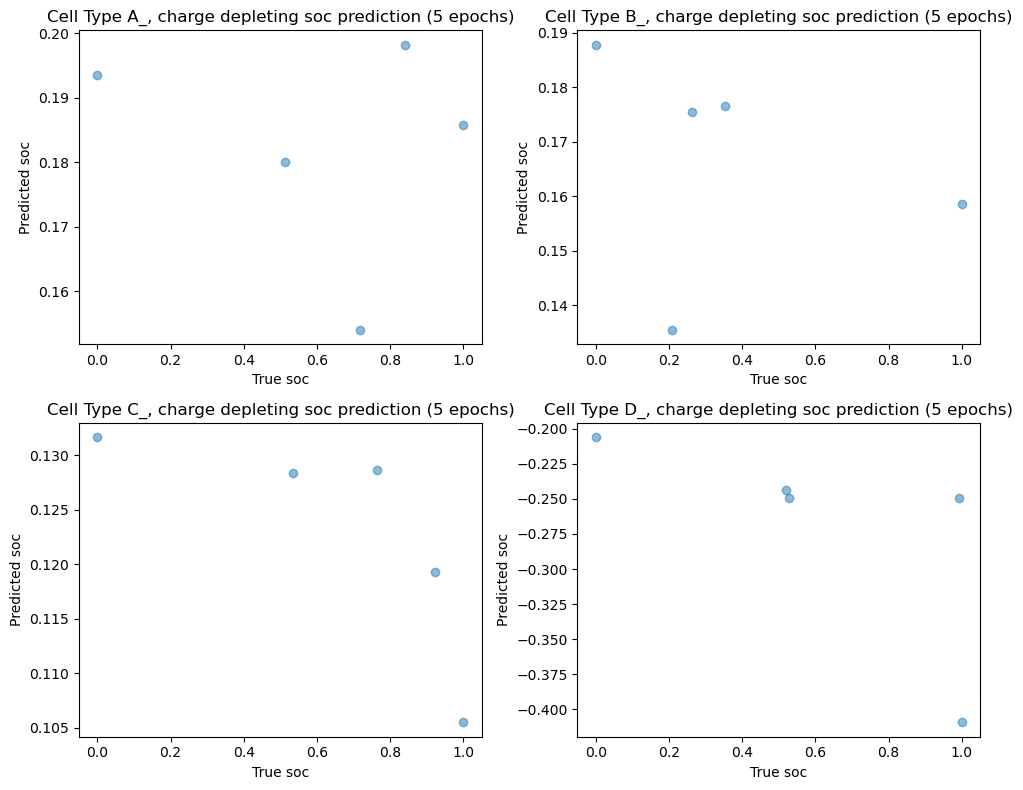

In [34]:

A_depleting_overfit = torch.load('../../results/neural_network/overfit_testing/Charge_Depleting_soc_mean_A_model.pth')
B_depleting_overfit = torch.load('../../results/neural_network/overfit_testing/Charge_Depleting_soc_mean_B_model.pth')
C_depleting_overfit = torch.load('../../results/neural_network/overfit_testing/Charge_Depleting_soc_mean_C_model.pth')
D_depleting_overfit = torch.load('../../results/neural_network/overfit_testing/Charge_Depleting_soc_mean_D_model.pth')

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax = ax.flatten()
df_all = hdf.get("Charge_Depleting")

for i, (cell_type, model_state) in enumerate(zip(["A_", "B_", "C_", "D_"], [
    A_depleting_overfit, B_depleting_overfit, C_depleting_overfit, D_depleting_overfit
])):
    df = df_all[df_all["cell_id"].str.startswith(cell_type)].reset_index(drop=True)

    # splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    # df = df.groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    # idx_train, idx_test = next(splitter.split(df, groups=df["measurement_id"]))
    # df_train = df.iloc[idx_train].reset_index(drop=True)
    # df_test = df.iloc[idx_test].reset_index(drop=True)
    df_train = df[df["split_type"] == "training"].reset_index(drop=True).groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    df_test = df[df["split_type"] == "testing"].reset_index(drop=True)

    random.seed(42)
    overfit_idxs = random.sample(range(len(df_train)), 5)
    df_train = df_train.iloc[overfit_idxs].reset_index(drop=True)
    df_test = df_train.copy().reset_index(drop=True)
    print(overfit_idxs)

    ax[i].set_title(f"Cell Type {cell_type}, charge depleting soc prediction (5 epochs)")
    test_dataloader = DataLoader(DataFrameDataset(df_train, target="C/3 discharge capacity", transform=ToTensor()), batch_size=64, shuffle=False)

    model = BasicRNN(input_size= 3, hidden_size=64, output_size=1)
    model.load_state_dict(model_state)
    model.eval()
    with torch.no_grad():
        for X, y in test_dataloader:
            outputs = model(X)
            print(outputs, y)
            ax[i].scatter(y.numpy(), outputs.numpy(), alpha=0.5)
            ax[i].set_xlabel("True soc")
            ax[i].set_ylabel("Predicted soc")
            # ax[i].set_ylim(0, 1)
            # ax[i].draw()

fig.tight_layout()